# **Project Overview**

The objective of this project was to identify the primary drivers of customer churn and build a predictive engine to flag high-risk customers. After engineering behavioral features (like Tenure_Bins) and preprocessing the data to prevent data leakage, an automated grid search tested four distinct machine learning architectures.

Ultimately, a heavily regularized Logistic Regression (C=100) model was selected for deployment. It achieved an F1-Score of ~0.56 on completely unseen test data. While complex tree-based models were tested, Logistic Regression was chosen because it perfectly balances predictive power with complete business interpretability—allowing us to see exactly why a customer is leaving.



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/python/projects /telecom customer churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# **Data Cleaning and Assessment**

In [ ]:
df.info()

# TotalCharges - Object Dtype - need investigation.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
missing_values = df.isna().sum()
missing_values[missing_values >0]

#No missing values calculated

,0


In [ ]:
for col in df.columns:
  print(df[col].value_counts())
  print("\n")

  # total charges has missing values, not stored as np.nan


customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64


gender
Male      3555
Female    3488
Name: count, dtype: int64


SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


Partner
No     3641
Yes    3402
Name: count, dtype: int64


Dependents
No     4933
Yes    2110
Name: count, dtype: int64


tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64


PhoneService
Yes    6361
No      682
Name: count, dtype: int64


MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


OnlineSecurity
No                     3498
Yes                    2019
No inte

In [ ]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

df["TotalCharges"] = df["TotalCharges"].astype("float")

print(df.loc[df["TotalCharges"].isna(), ["MonthlyCharges", "tenure"]])

df["TotalCharges"] = df["TotalCharges"].fillna(0.0)

# Total charges missing were cases were of new customers.
# Replaced np.nan with 0.0 to maintain data integrity.

      MonthlyCharges  tenure
488            52.55       0
753            20.25       0
936            80.85       0
1082           25.75       0
1340           56.05       0
3331           19.85       0
3826           25.35       0
4380           20.00       0
5218           19.70       0
6670           73.35       0
6754           61.90       0


# **EDA**

In [ ]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

# converting Yes/No in Churn column to 1/0 for analysis.

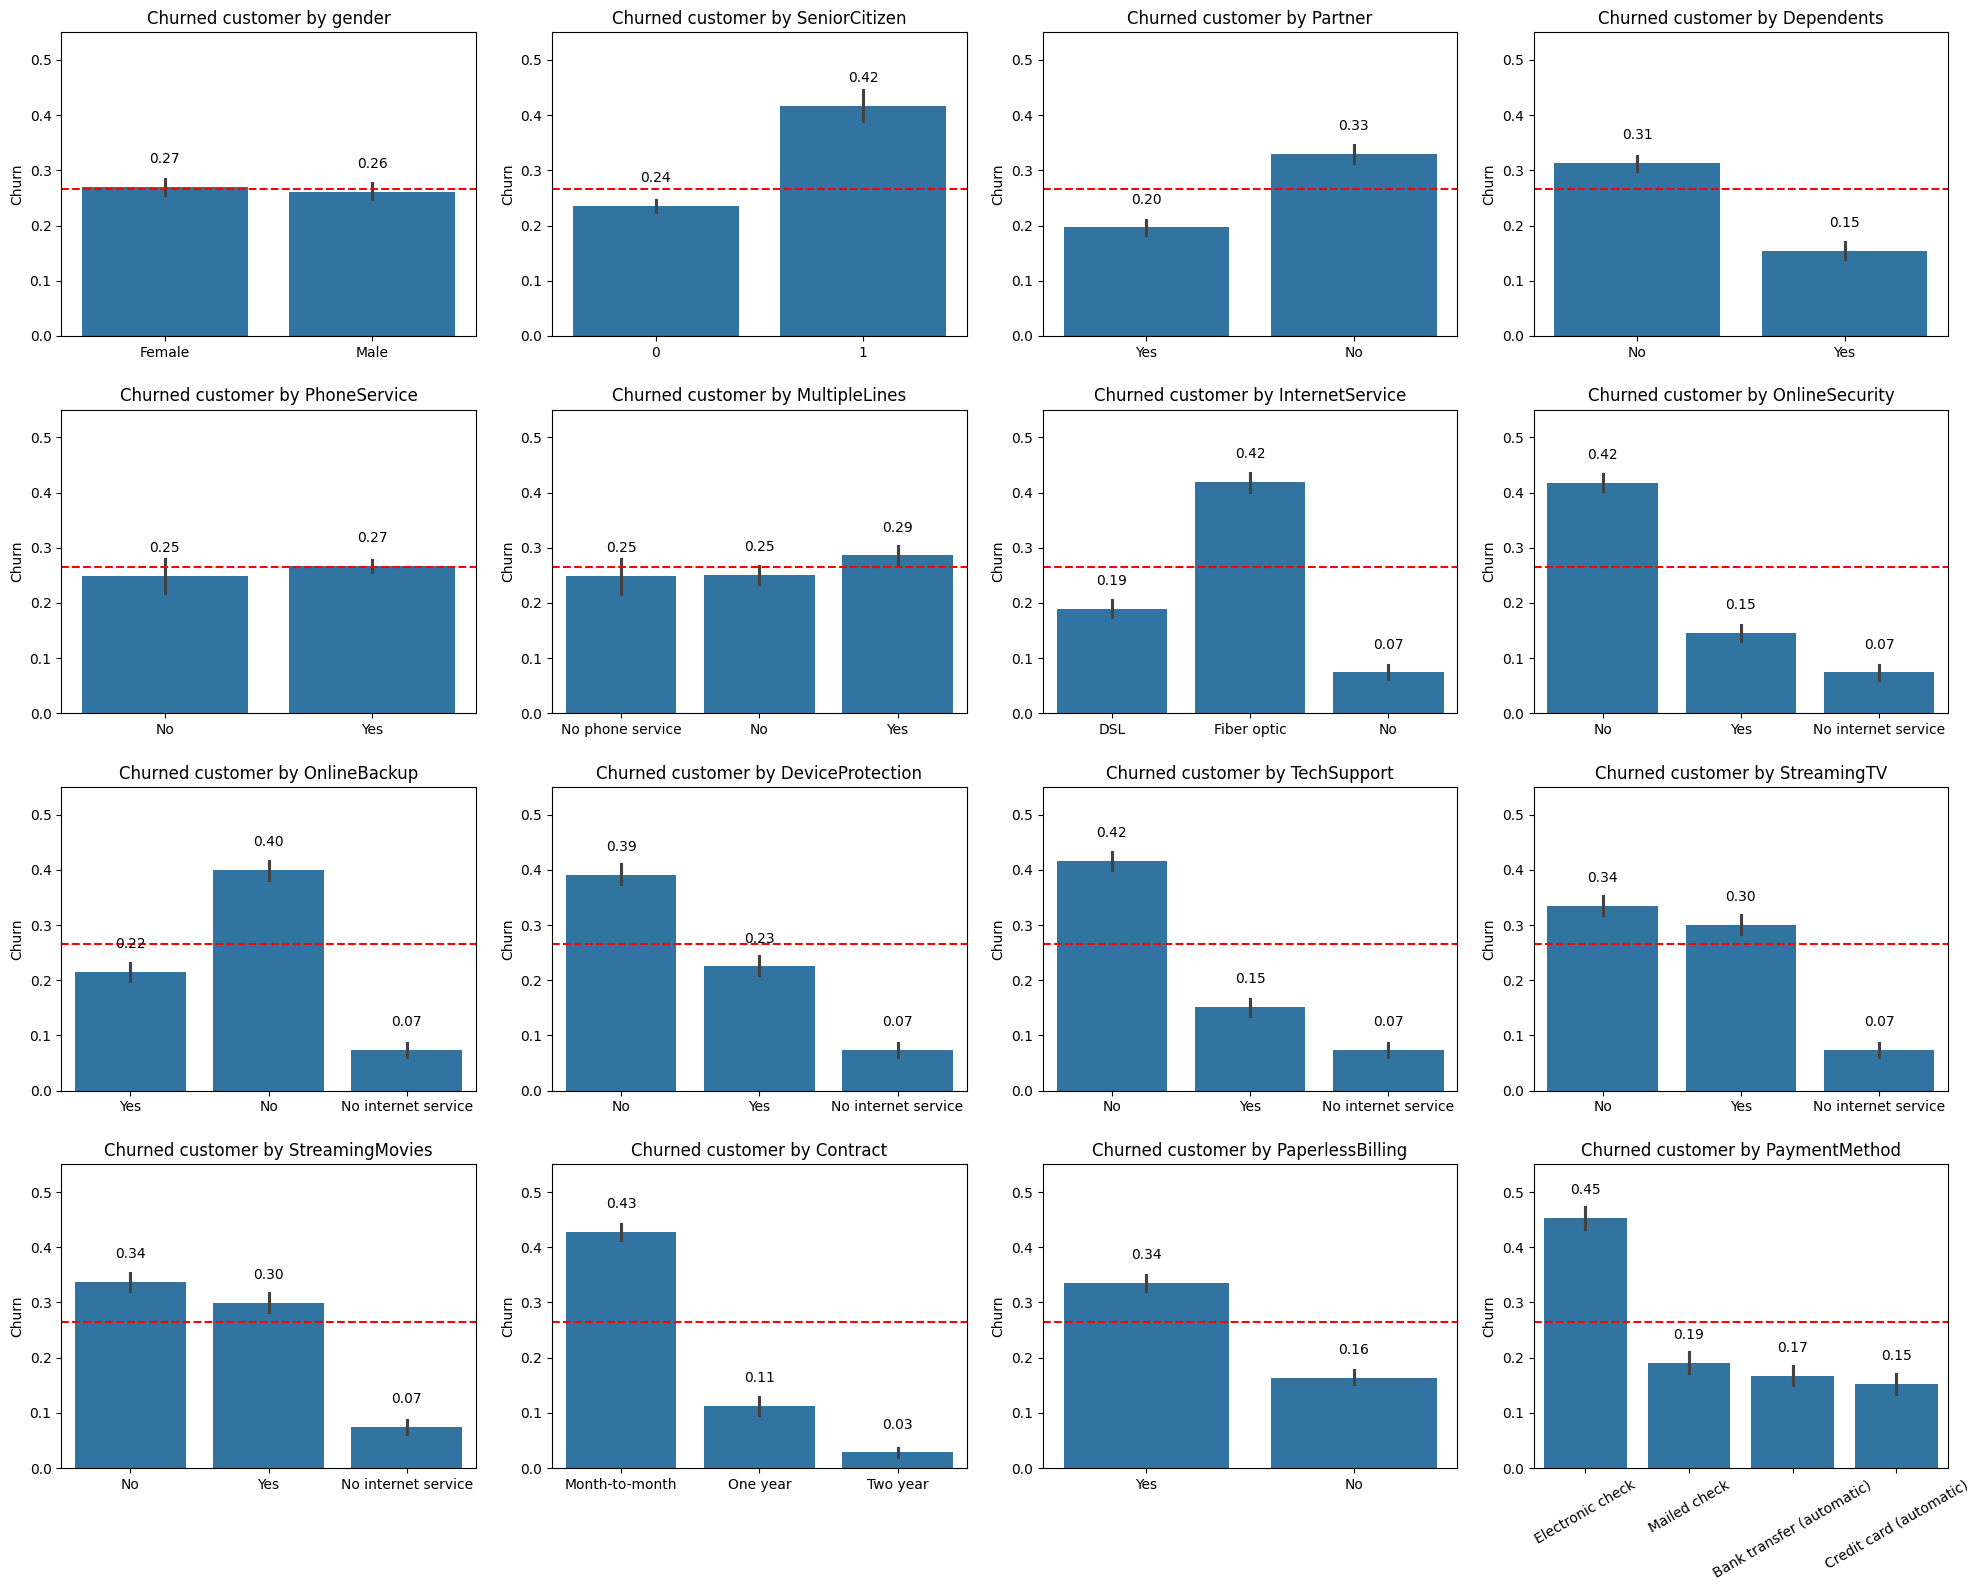

In [ ]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService','MultipleLines',
 'InternetService','OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling','PaymentMethod']

fig, axes = plt.subplots(nrows = 4, ncols = 4, figsize = (20,16))

axes = axes.flatten()

for i, col in enumerate(cat_cols):
  sns.barplot(data = df, x = col, y = "Churn", ax = axes[i])

  for container in axes[i].containers:
    axes[i].bar_label(container, fmt = "%.2f", padding = 15)

  axes[i].set_title(f"Churned customer by {col}")
  axes[i].set_ylim(0, 0.55)
  axes[i].axhline(df["Churn"].mean(), linestyle = "--", color = "red")


  axes[i].set_xlabel("")

axes[15].tick_params(axis = "x", rotation = 30)
plt.tight_layout(h_pad = 2)
plt.show()

***Learnings***

Customers on Month-to-month contracts are churning at an alarming rate (~43%), whereas those on 1-year or 2-year contracts have almost zero churn.

Counterintuitively, premium Fiber Optic internet users churn significantly more (~42%) than basic DSL users (~19%). This strongly indicates a service reliability issue or a mismatch in price-to-value expectation.

Customers paying via Electronic Check churn at nearly double the rate of automatic payment methods (Credit Card / Bank Transfer).

Lack of "Sticky" Services: Customers who lack complementary services like Tech Support, Online Security, and Device Protection are highly vulnerable to churning.

Having a dependent/Partner added to the service - Has lower Churn rate.

Paperless Billing has higher Churn rate then not

In [ ]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

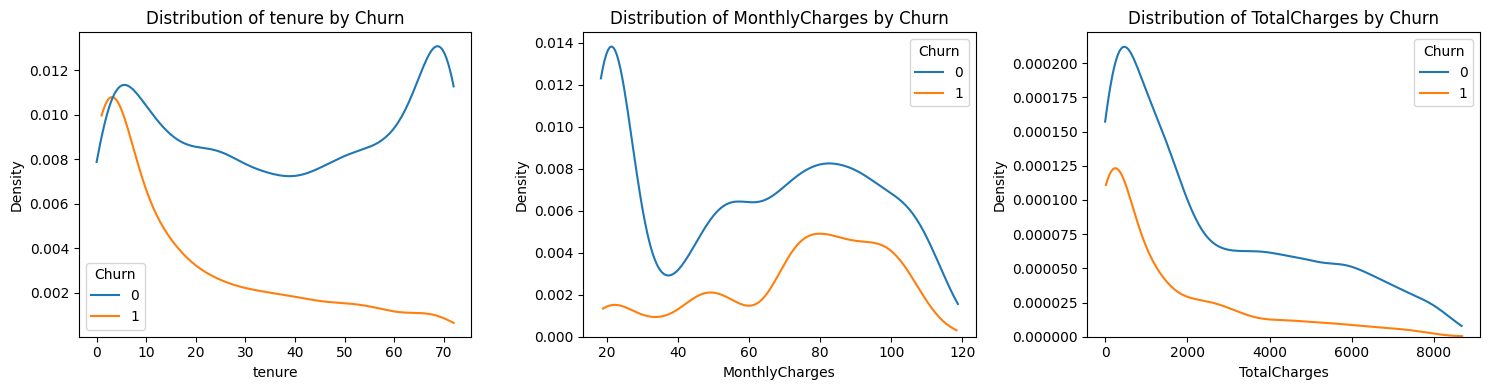

In [ ]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (15,4))

axes = axes.flatten()

for i,col in enumerate(num_cols):
  sns.kdeplot(data = df, x = col, hue = "Churn", ax = axes[i], cut = 0)

  axes[i].set_title(f"Distribution of {col} by Churn")


plt.tight_layout()
plt.show()

The tenure distribution reveals a severe onboarding crisis. The vast majority of churn occurs in the first 6 months. Actionable Insight: The business must overhaul its onboarding experience, perhaps offering a "Month 3 Check-in" or an introductory rate that locks in a 1-year commitment.

The MonthlyCharges distribution shows excellent retention for budget users (~$20/month).However Churn increases at higher monthly rate.

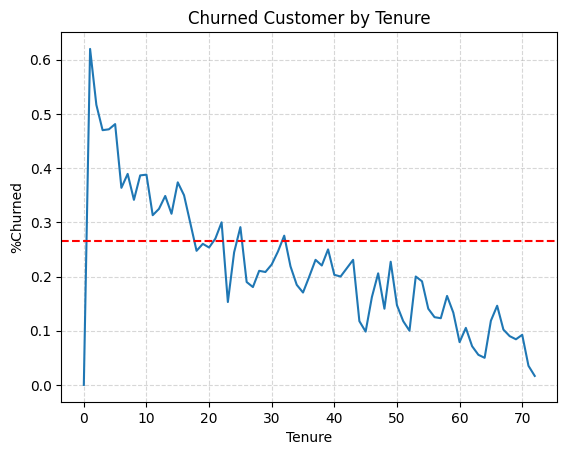

In [ ]:
tenure_churn = df.groupby("tenure")["Churn"].mean()

plt.plot(tenure_churn.index, tenure_churn.values)
plt.axhline(df["Churn"].mean(), color = "red", linestyle = "--")
plt.title("Churned Customer by Tenure")
plt.ylabel("%Churned")
plt.xlabel("Tenure")
plt.grid(alpha = 0.5, linestyle = "--", axis = "both", visible = True)
plt.show()

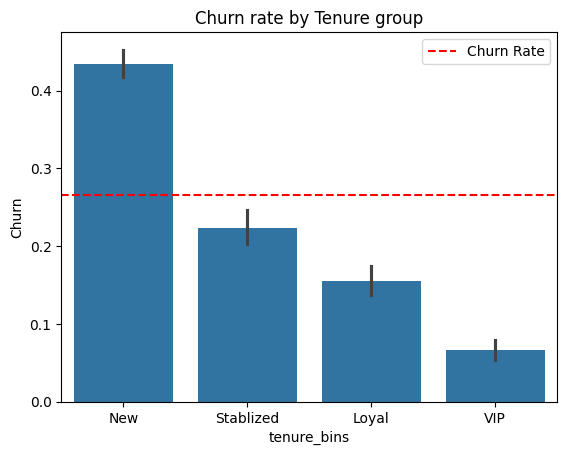

In [ ]:
df["tenure_bins"] = pd.cut(df["tenure"], bins = [-1,20,40,60, np.inf], labels = ["New","Stablized","Loyal", "VIP" ])


sns.barplot(data =df, x = "tenure_bins", y ="Churn")
plt.axhline(df["Churn"].mean(), linestyle = "--", color = "red", label = "Churn Rate")
plt.title("Churn rate by Tenure group")
plt.legend()
plt.show()

"To capture the non-linear relationship between tenure and churn, I engineered a categorical tenure_bins feature using 20-month intervals. The visualization validates this strategy: it perfectly isolates the high-risk onboarding phase (0-20 months at ~44% churn) from the stabilization and loyalty phases, providing a much clearer signal for the Machine Learning model than a raw continuous variable."

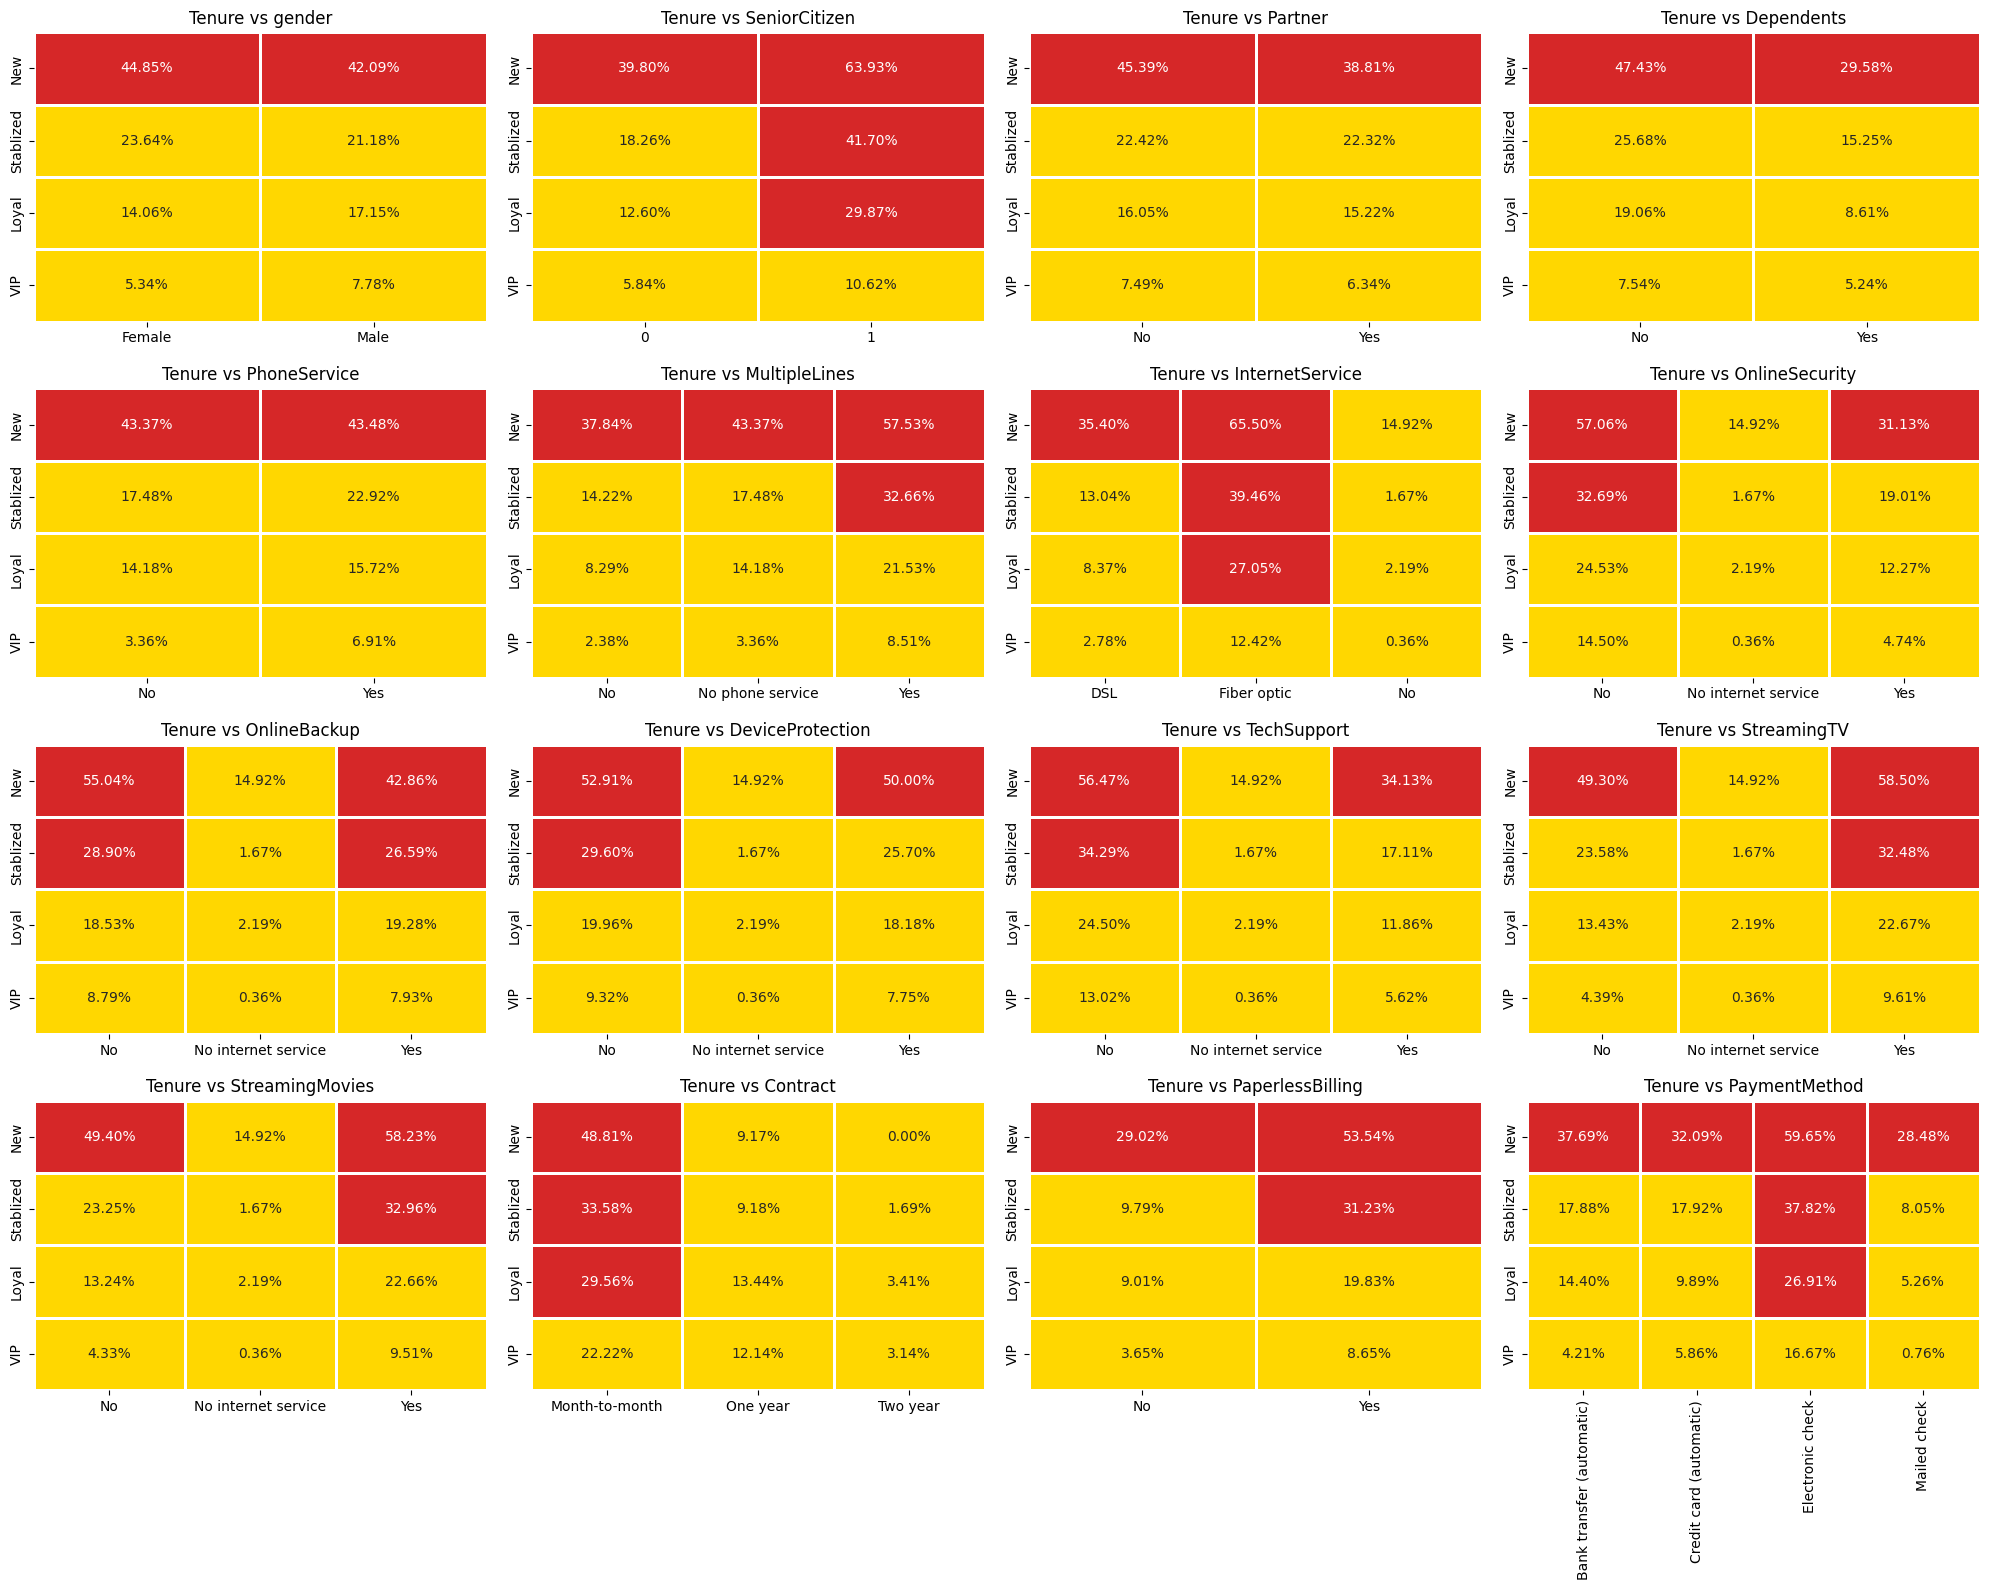

In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm

custom_cmap = ListedColormap(['#FFD700', '#D62728'])
bounds = [0, df["Churn"].mean(), 1.0]
custom_norm = BoundaryNorm(bounds, custom_cmap.N)

fig, axes = plt.subplots(nrows = 4, ncols = 4, figsize = (20,16))

axes = axes.flatten()

for i, col in enumerate(cat_cols):
  pivot = df.pivot_table(index = "tenure_bins", columns = col, values = "Churn", aggfunc = "mean", observed = False)

  sns.heatmap(pivot, annot = True, cmap = custom_cmap, ax = axes[i], norm = custom_norm,
              fmt = ".2%", linecolor = "white", cbar = False, linewidth = 1)
  axes[i].set_title(f"Tenure vs {col}")
  axes[i].set_ylabel("")
  axes[i].set_xlabel("")

plt.tight_layout(h_pad = 1.5, w_pad = 1.5)
plt.show()

These four critical segments are:
Senior Citizens (Yes)
Internet Service (Fiber Optic)
Contract (Month-to-Month)
Payment Method (Electronic Check)

Here are the three strategic business learnings derived from these specific cohorts:
1. Time Does Not Heal All Wounds (Sustained Flight Risk): Unlike normal friction points that naturally resolve as a customer gets used to the service, these four segments suffer from "chronic churn." The fact that they stay red for three consecutive bins proves that simply waiting for these customers to mature will not save them; the company is actively bleeding revenue from them year after year.
2. The "High-Friction" Denominator: These four groups share a common psychological theme: high effort and high expectations. Electronic Checks force customers to manually pay every single month. Month-to-Month contracts offer zero barrier to leaving. Fiber Optic users pay premium prices and expect flawless speeds, while Senior Citizens often face technical hurdles that require dedicated, patient support.
3. Aggressive Intervention is Required: Because time alone does not fix these cohorts, the business must actively disrupt their behavior. Passive retention strategies will fail. The primary goals must be shifting Electronic Check users to Auto-Pay (via discounts), upselling Month-to-Month users to 1-year contracts, and instituting proactive "white-glove" technical support for Seniors and Fiber users to justify the premium costs.


# **Data Preprocessing and ML Model**

In [ ]:
df_model = df.drop(columns=['customerID', 'tenure', 'TotalCharges'])

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df_model[col] = df_model[col].map({'Yes': 1, 'No': 0})

df_model['gender'] = df_model['gender'].map({'Female': 1, 'Male': 0})

df_encoded = pd.get_dummies(df_model, drop_first=True, dtype=int)

# Check the transformation
print(f"Original shape before encoding: {df.shape}")
print(f"Final shape ready for Machine Learning: {df_encoded.shape}")

# Display the first few rows
df_encoded.head()



Original shape before encoding: (7043, 22)
Final shape ready for Machine Learning: (7043, 32)


,gender,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,MonthlyCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_bins_Stablized,tenure_bins_Loyal,tenure_bins_VIP
0,1,0,1,0,0,1,29.85,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,1,0,56.95,0,0,0,...,0,0,1,0,0,0,1,1,0,0
2,0,0,0,0,1,1,53.85,1,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0,0,0,0,0,0,42.30,0,1,0,...,0,0,1,0,0,0,0,0,1,0
4,1,0,0,0,1,1,70.70,1,0,0,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
x = df_encoded.drop(columns = ["Churn"])
y = df_encoded["Churn"]

x_train, x_test, y_train, y_test = train_test_split(x,y, stratify = y, test_size = 0.2, random_state =11)

trans = ColumnTransformer(transformers = [("scaler", StandardScaler(), ["MonthlyCharges"])],
                           remainder = "passthrough")

pipeline = Pipeline([("trans", trans),
                     ("model", LogisticRegression())])

param_grid = [{"trans":[trans], "model": [LogisticRegression()], "model__C":[0.001,0.01, 0.1, 10,100]},
              {"trans":[trans], "model": [KNeighborsClassifier()],"model__n_neighbors": [2,3,5,7,9,10]},
              {"trans":[trans], "model": [DecisionTreeClassifier(random_state = 11)],"model__max_depth":[2,3,5,7,10]},
              {"trans":[trans], "model": [RandomForestClassifier(random_state = 11)],"model__max_depth": [2,3,5,7,10], "model__n_estimators":[50,100,150,200]}]

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 13)

grid = GridSearchCV(pipeline, param_grid, cv = cv,
                    scoring = ["f1", "recall", "precision", "accuracy", "roc_auc"],
                    refit = "f1", n_jobs = -1)

In [ ]:
grid.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=13, shuffle=True),
             estimator=Pipeline(steps=[('trans',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('scaler',
                                                                         StandardScaler(),
                                                                         ['MonthlyCharges'])])),
                                       ('model', LogisticRegression())]),
             n_jobs=-1,
             param_grid=[{'model': [LogisticRegression()],
                          'model__C': [0.001, 0.01, 0.1, 10, 100],
                          'trans': [Colum...
                                                      transformers=[('scaler',
                                                                     StandardScaler(),
                                                                     ['MonthlyCharges'])])]},
                         {'model': [RandomForestClassifier(random_state=11)],
                          'model__max_depth': [2, 3, 5, 7, 10],
                          'model__n_estimators': [50, 100, 150, 200],
                          'trans': [ColumnTransformer(remainder='passthrough',
                                                      transformers=[('scaler',
                                                                     StandardScaler(),
                                                                     ['MonthlyCharges'])])]}],
             refit='f1',
             scoring=['f1', 'recall', 'precision', 'accuracy', 'roc_auc'])

In [ ]:
grid.best_params_

{'model': LogisticRegression(),
 'model__C': 100,
 'trans': ColumnTransformer(remainder='passthrough',
                   transformers=[('scaler', StandardScaler(),
                                  ['MonthlyCharges'])])}

In [ ]:
grid.best_score_

np.float64(0.5879742456089556)

In [ ]:
grid.score(x_test, y_test)

0.5619335347432024

In [ ]:
results = pd.DataFrame(grid.cv_results_)[["param_model","mean_test_recall", "mean_test_precision", "mean_test_accuracy", "mean_test_roc_auc", "mean_test_f1"]]

results.columns = ["model", "recall", "precision", "accuracy", "roc_auc", "f1"]
results["model"] = results["model"].astype("str").str.split("(").str[0]

results.head()

,model,recall,precision,accuracy,roc_auc,f1
0,LogisticRegression,0.000000,0.000000,0.734647,0.812632,0.000000
1,LogisticRegression,0.390635,0.683227,0.789844,0.832072,0.496741
2,LogisticRegression,0.514381,0.660557,0.800850,0.839511,0.578198
3,LogisticRegression,0.529766,0.658181,0.802091,0.839430,0.586915
4,LogisticRegression,0.531104,0.658692,0.802446,0.839307,0.587974


In [ ]:
result_melt = results.melt(id_vars = "model", var_name = "metrics", value_name = "score")

result_melt.head()

,model,metrics,score
0,LogisticRegression,recall,0.000000
1,LogisticRegression,recall,0.390635
2,LogisticRegression,recall,0.514381
3,LogisticRegression,recall,0.529766
4,LogisticRegression,recall,0.531104


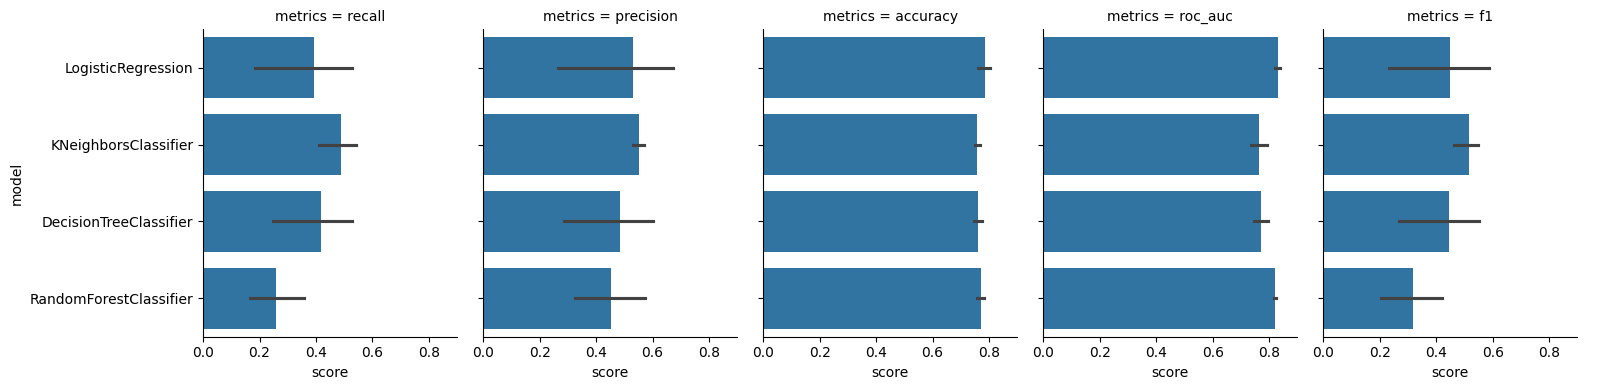

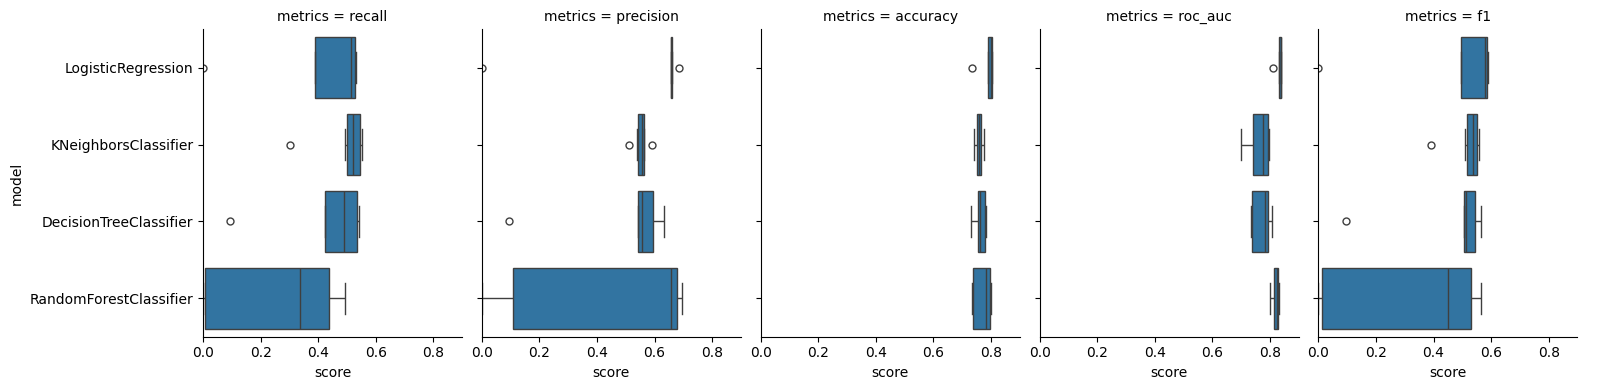

In [ ]:
g1 = sns.catplot(data=result_melt,
                 y="model", x="score", col="metrics",
                 kind="bar", height=4, aspect=0.8)
g1.set(xlim=(0, 0.9))
plt.show()


g2 = sns.catplot(data=result_melt,
                 y="model", x="score", col="metrics",
                 kind="box", height=4, aspect=0.8)
g2.set(xlim=(0, 0.9))
plt.show()

In [ ]:
grid.best_estimator_

Pipeline(steps=[('trans',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['MonthlyCharges'])])),
                ('model', LogisticRegression(C=100))])

In [ ]:
coef = grid.best_estimator_.named_steps["model"].coef_[0]

features = grid.best_estimator_.named_steps["trans"].feature_names_in_

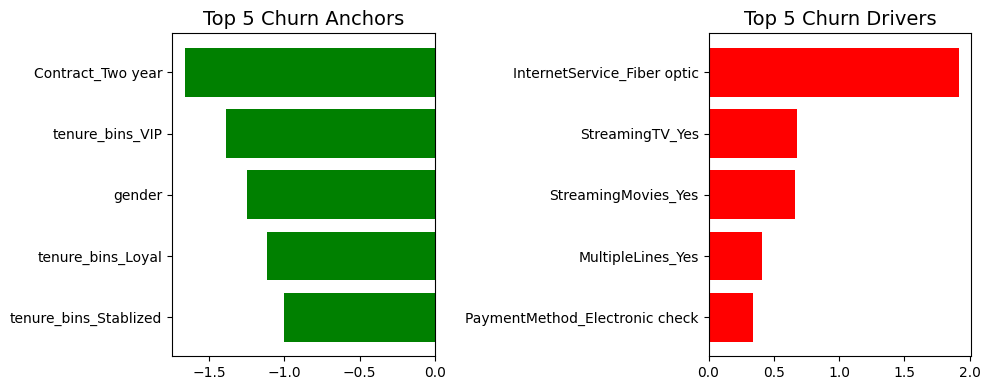

In [ ]:
importance_df = pd.DataFrame({"features":features, "coefficient": coef})

anchors = importance_df.sort_values(by = "coefficient", ascending = True).head()

drivers = importance_df.sort_values(by = "coefficient", ascending = False).head()

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

#anchors have NEGATIVE coefficients
axes[0].barh(anchors["features"], anchors["coefficient"], color='green')
axes[0].set_title("Top 5 Churn Anchors", fontsize=14)
axes[0].invert_yaxis()

# drivers have POSITIVE coefficients
axes[1].barh(drivers["features"], drivers["coefficient"], color='red')
axes[1].set_title("Top 5 Churn Drivers", fontsize=14)
axes[1].invert_yaxis()


plt.tight_layout()
plt.show()

# **Model Conclusion**

"Through rigorous hyperparameter tuning and cross-validation across four distinct algorithmic architectures, a heavily regularized Logistic Regression (C=100) was selected as the production model. It achieved an F1-Score of ~0.56 on completely unseen test data. More importantly, it successfully captured the majority of actual churners (high Recall) while remaining computationally lightweight and 100% interpretable."

# **Business Recommendations**

The Fiber Optic Paradox: Fiber Optic internet is our strongest churn driver (highest positive coefficient). The business must investigate if this is a pricing issue or a service reliability (outage) issue.

Contract Migration: Month-to-Month contracts offer zero barrier to exit. Marketing should run a targeted campaign offering the highest-risk customers a 10% discount to lock into a 1-Year or 2-Year contract, which our model proves is the ultimate loyalty anchor.

Payment Friction: Electronic Check users are churning at a higher rate. We should offer a one-time $5 statement credit for users who switch to Auto-Pay via Credit Card."